In [ ]:
!pip install keras-tuner --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt

from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense
from sklearn.preprocessing import MinMaxScaler, StandardScaler

##############################################################################
# 1) Utility Functions for Data Preparation
##############################################################################
def compute_rsi(series, period=14):
    delta = series.diff().dropna()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def add_datetime_features(df):
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")
    df["Weekday"]   = df["Timestamp"].dt.weekday
    df["Day"]       = df["Timestamp"].dt.day
    df["Year"]      = df["Timestamp"].dt.year.astype(float)

    df["TOD"]       = df["Timestamp"].dt.hour + df["Timestamp"].dt.minute/60.0

    month           = df["Timestamp"].dt.month
    df["Month_Sin"] = np.sin(2 * np.pi * month / 12.0)
    df["Month_Cos"] = np.cos(2 * np.pi * month / 12.0)

    df["TOD_Sin"]   = np.sin(2 * np.pi * df["TOD"] / 24.0)
    df["TOD_Cos"]   = np.cos(2 * np.pi * df["TOD"] / 24.0)

    df.drop(columns=["Timestamp", "TOD"], inplace=True)
    return df

def add_features(df):
    df["SMA_10"]   = df["Close"].rolling(window=10).mean()
    df["SMA_50"]   = df["Close"].rolling(window=50).mean()
    df["RSI_14"]   = compute_rsi(df["Close"])
    df["Return"]   = df["Close"].pct_change()

    df["Middle_Band"] = df["Close"].rolling(window=20).mean()
    stddev = df["Close"].rolling(window=20).std()
    df["Upper_Band"]  = df["Middle_Band"] + (2 * stddev)
    df["Lower_Band"]  = df["Middle_Band"] - (2 * stddev)

    df = add_datetime_features(df)
    df["Target"] = df["Close"].shift(-1)
    return df

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i+seq_length, :-1])
        y.append(data[i + seq_length, -1])
    return np.array(X), np.array(y)

def prepare_data(filepath, scaling_method="minmax", seq_length=30, val_fraction=0.15):
    df = pd.read_csv(filepath)
    df.columns = ["Timestamp", "Open", "High", "Low", "Close", "Volume", "Trades"]
    df = df.reset_index(drop=True)

    n = len(df)
    train_end = int(0.7 * n)
    val_size  = int(val_fraction * n)
    val_end   = train_end + val_size

    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()

    train_df = add_features(train_df)
    val_df   = add_features(val_df)
    test_df  = add_features(test_df)

    train_means = train_df.mean(numeric_only=True)
    train_df.fillna(train_means, inplace=True)
    val_df.fillna(train_means, inplace=True)
    test_df.fillna(train_means, inplace=True)

    if scaling_method == "minmax":
        scaler = MinMaxScaler()
    elif scaling_method == "standard":
        scaler = StandardScaler()
    else:
        raise ValueError(f"Invalid scaling method: {scaling_method}")

    exclude_cols = ["Month_Sin", "Month_Cos", "TOD_Sin", "TOD_Cos"]
    features_to_scale = [c for c in train_df.columns if c not in exclude_cols]

    scaler.fit(train_df[features_to_scale])
    train_df[features_to_scale] = scaler.transform(train_df[features_to_scale])
    val_df[features_to_scale]   = scaler.transform(val_df[features_to_scale])
    test_df[features_to_scale]  = scaler.transform(test_df[features_to_scale])

    def reorder(d):
        cols = list(d.columns)
        cols.remove("Target")
        cols.append("Target")
        return d[cols]

    train_df = reorder(train_df)
    val_df   = reorder(val_df)
    test_df  = reorder(test_df)

    train_data = train_df.to_numpy()
    val_data   = val_df.to_numpy()
    test_data  = test_df.to_numpy()

    X_train, y_train = create_sequences(train_data, seq_length)
    X_val,   y_val   = create_sequences(val_data,   seq_length)
    X_test,  y_test  = create_sequences(test_data,  seq_length)

    X_train, y_train = X_train[:-1], y_train[:-1]
    X_val,   y_val   = X_val[:-1],   y_val[:-1]
    X_test,  y_test  = X_test[:-1],  y_test[:-1]

    return X_train, y_train, X_val, y_val, X_test, y_test

##############################################################################
# 2) Custom HyperModel with build(...) and fit(...)
##############################################################################
class FullSearchHyperModel(kt.HyperModel):
    def build(self, hp):
        self.scaling_method = hp.Choice("scaling_method", ["minmax", "standard"])
        self.seq_length     = hp.Int("seq_length", 10, 60, step=10)
        self.val_fraction   = hp.Float("val_fraction", 0.1, 0.3, step=0.1)

        (self.X_train,
         self.y_train,
         self.X_val,
         self.y_val,
         self.X_test,
         self.y_test) = prepare_data(
            filepath="XBTUSD_15.csv",
            scaling_method=self.scaling_method,
            seq_length=self.seq_length,
            val_fraction=self.val_fraction
        )

        num_features = self.X_train.shape[2]

        model = tf.keras.Sequential()
        num_lstm_layers = hp.Int("num_lstm_layers", min_value=1, max_value=3, step=1)

        for i in range(num_lstm_layers):
            units = hp.Int(f"lstm_units_{i}", 32, 128, step=32)
            return_seq = (i < num_lstm_layers - 1)
            if i == 0:
                model.add(Bidirectional(
                    LSTM(units, return_sequences=return_seq,
                         input_shape=(self.seq_length, num_features))
                ))
            else:
                model.add(LSTM(units, return_sequences=return_seq))

            dp = hp.Float(f"dropout_rate_{i}", 0.0, 0.5, step=0.1)
            model.add(Dropout(dp))

        dense_units = hp.Int("dense_units", 16, 128, step=16)
        dense_act   = hp.Choice("dense_activation", ["relu", "tanh", "sigmoid"])
        model.add(Dense(dense_units, activation=dense_act))

        model.add(Dense(1))

        optimizer_choice = hp.Choice("optimizer", ["adam", "sgd", "rmsprop"])
        learning_rate = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")

        if optimizer_choice == "adam":
            optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        elif optimizer_choice == "sgd":
            optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
        elif optimizer_choice == "rmsprop":
            optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

        loss_choice = hp.Choice("loss", ["mse", "mae"])
        model.compile(
            optimizer=optimizer,
            loss=loss_choice,
            metrics=["mae"]
        )

        return model

    def fit(self, hp, model, *args, **kwargs):
        batch_size = hp.Int("batch_size", 16, 128, step=16)

        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        callbacks = kwargs.pop('callbacks', [])
        callbacks.append(early_stopping)

        return model.fit(
            self.X_train, self.y_train,
            validation_data=(self.X_val, self.y_val),
            epochs=100,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0,
            **kwargs
        )

##############################################################################
# 3) Use Bayesian Optimization Tuner
##############################################################################
from keras_tuner.tuners import BayesianOptimization

tuner = BayesianOptimization(
    hypermodel=FullSearchHyperModel(),
    objective="val_loss",
    max_trials=100,
    seed=42,
    project_name="btc_lstm_full_tuning_allinone",
    overwrite=True
)

tuner.search()


Trial 100 Complete [00h 00m 13s]
val_loss: 0.029111254960298538

Best val_loss So Far: 0.001988752745091915
Total elapsed time: 00h 55m 57s


Results summary
Results in ./btc_lstm_full_tuning_allinone
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 049 summary
Hyperparameters:
scaling_method: minmax
seq_length: 30
val_fraction: 0.2
num_lstm_layers: 1
lstm_units_0: 64
dropout_rate_0: 0.2
dense_units: 48
dense_activation: tanh
optimizer: adam
learning_rate: 0.0032140183480912376
loss: mse
batch_size: 16
lstm_units_1: 96
dropout_rate_1: 0.2
lstm_units_2: 96
dropout_rate_2: 0.1
Score: 0.001988752745091915

Trial 071 summary
Hyperparameters:
scaling_method: minmax
seq_length: 40
val_fraction: 0.2
num_lstm_layers: 1
lstm_units_0: 32
dropout_rate_0: 0.0
dense_units: 64
dense_activation: tanh
optimizer: rmsprop
learning_rate: 0.003975267008309707
loss: mse
batch_size: 80
lstm_units_1: 128
dropout_rate_1: 0.4
lstm_units_2: 128
dropout_rate_2: 0.4
Score: 0.0028721075505018234

Trial 078 summary
Hyperparameters:
scaling_method: minmax
seq_length: 50
val_fraction: 0.1
num_lstm_layers: 1
lstm_units_0: 32
dropout

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (16, 128)                   │          43,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (16, 128)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (16, 48)                    │           6,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (16, 1)                     │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,761 (194.38 KB)

 Trainable params: 49,761 (194.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0012 - mae: 0.0216 - val_loss: 0.0019 - val_mae: 0.0306
Epoch 2/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.5639e-04 - mae: 0.0169 - val_loss: 0.0037 - val_mae: 0.0440
Epoch 3/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.3553e-04 - mae: 0.0132 - val_loss: 0.0030 - val_mae: 0.0381
Epoch 4/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.8878e-04 - mae: 0.0141 - val_loss: 0.0023 - val_mae: 0.0347
Epoch 5/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.4832e-04 - mae: 0.0120 - val_loss: 0.0023 - val_mae: 0.0337
Epoch 6/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.8276e-04 - mae: 0.0130 - val_loss: 0.0034 - val_mae: 0.0400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0051 - mae: 0.0500  

Final Test Loss: 0.010263859294354916
Final Test MAE: 0.08143854141235352


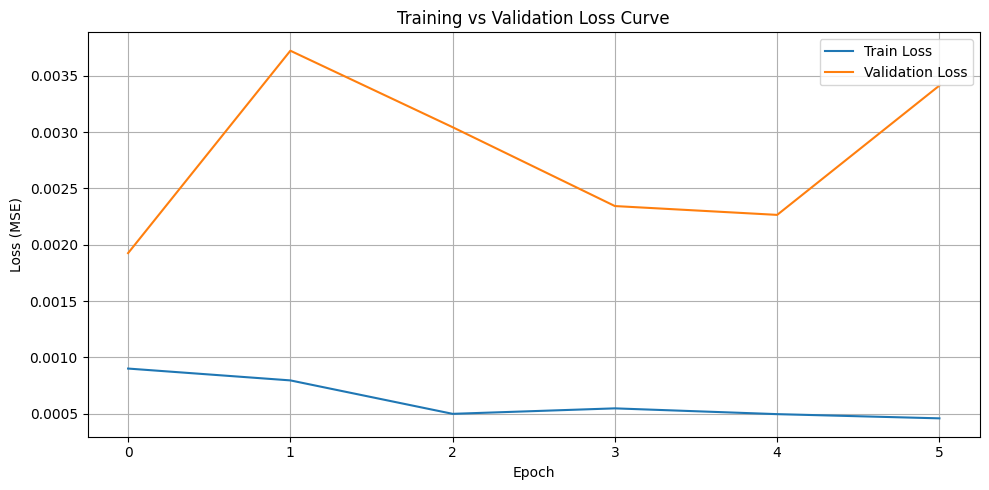

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


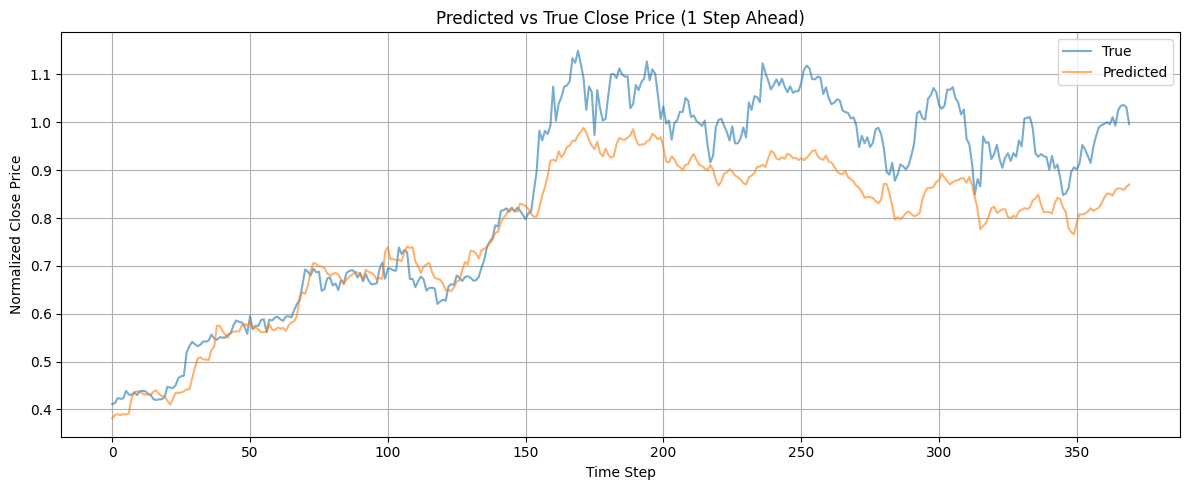

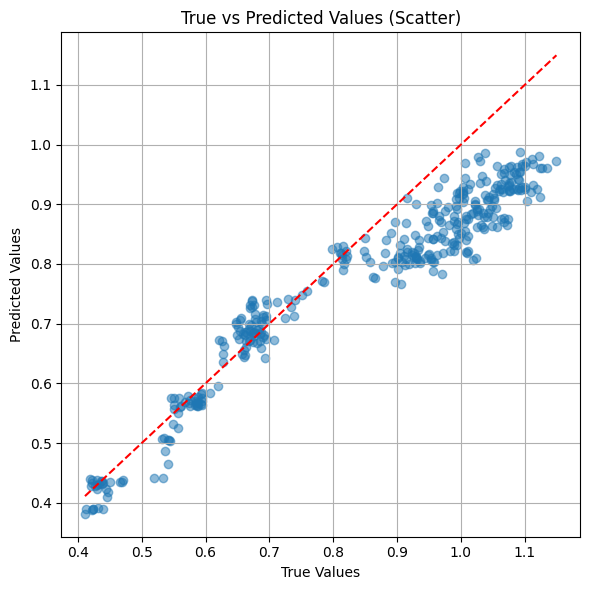

Prediction-Target Correlation: 0.9651

--- Naïve Forecast (Scaled) ---
Naive MSE: 0.0005855923403775857
Naive MAE: 0.016776583817471664

--- Model (Scaled) ---
Model MSE: 0.010263860132840082
Model MAE: 0.08143853683757755

Skill Score (1 - MSE_model/MSE_naive): -16.527312816663585

--- Unscaled (Dollars) ---
Model MSE (dollars): 54634361.6419606
Model MAE (dollars): 5941.656495147366
Naive MSE (dollars): 3117099.266351946
Naive MAE (dollars): 1223.9992556563134

Mean Absolute Percentage Error (Model): 8.66%


In [ ]:
##############################################################################
# 4) Results & Summaries
##############################################################################
tuner.results_summary()

# Gather all trials
all_trials = tuner.oracle.get_best_trials(num_trials=20)
records = []
for t in all_trials:
    hps  = t.hyperparameters.values
    loss = t.metrics.get_last_value("val_loss")
    row  = {**hps, "val_loss": loss}
    records.append(row)

df = pd.DataFrame(records).sort_values("val_loss")
print("\nTop Trials (Sorted by val_loss):")
print(df.head(5))

##############################################################################
# 5) Evaluate on the Test Set With the Best Model
##############################################################################
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBEST HYPERPARAM COMBINATION:")
print(best_hp.values)

best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

# Re-run data prep with best hyperparams
best_scaling = best_hp.get("scaling_method")
best_seq_len = best_hp.get("seq_length")
best_val_frac = best_hp.get("val_fraction")

X_train, y_train, X_val, y_val, X_test, y_test = prepare_data(
    "XBTUSD_15.csv",
    scaling_method=best_scaling,
    seq_length=best_seq_len,
    val_fraction=best_val_frac
)

# Add EarlyStopping for final training
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Re-train with early stopping (epochs no longer in hyperparams)
history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,  # Fixed high number with early stopping
    batch_size=best_hp.get("batch_size"),
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on test set
test_loss, test_mae = best_model.evaluate(X_test, y_test, verbose=1)
print("\nFinal Test Loss:", test_loss)
print("Final Test MAE:", test_mae)

##############################################################################
# 6) Visualization & Performance Analysis
##############################################################################

# 1. Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Predictions vs True Values (Time Series)
preds = best_model.predict(X_test).flatten()

plt.figure(figsize=(12, 5))
plt.plot(y_test, label="True", alpha=0.6)
plt.plot(preds, label="Predicted", alpha=0.6)
plt.title("Predicted vs True Close Price (1 Step Ahead)")
plt.xlabel("Time Step")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Scatter Plot with Correlation
plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values (Scatter)")
plt.grid(True)
plt.tight_layout()
plt.show()

correlation = np.corrcoef(y_test, preds)[0, 1]
print("Prediction-Target Correlation: {:.4f}".format(correlation))


##############################################################################
# 7) Baseline Comparison, Skill Score, and Dollar/Percentage Errors
##############################################################################

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ------------------------------------------------------------------------------
# A. NAÏVE FORECAST IN THE SCALED DOMAIN
# ------------------------------------------------------------------------------

# We'll shift y_test by 1 step. That means naive_preds[t] = y_test[t-1].
naive_preds = np.zeros_like(y_test)
naive_preds[1:] = y_test[:-1]  # shift by 1
naive_preds[0]  = y_test[0]    # or could be set to 0 or np.nan

# MSE & MAE of naive forecast (scaled domain)
naive_mse  = mean_squared_error(y_test, naive_preds)
naive_mae  = mean_absolute_error(y_test, naive_preds)

# MSE & MAE of model forecast (scaled domain) – we already have `test_loss` (usually MSE)
# and `test_mae`. But let's re-confirm with scikit-learn so we can do a skill score:

model_mse_scaled = mean_squared_error(y_test, preds)
model_mae_scaled = mean_absolute_error(y_test, preds)

print("\n--- Naïve Forecast (Scaled) ---")
print("Naive MSE:", naive_mse)
print("Naive MAE:", naive_mae)

print("\n--- Model (Scaled) ---")
print("Model MSE:", model_mse_scaled)
print("Model MAE:", model_mae_scaled)

# ------------------------------------------------------------------------------
# B. Skill Score (for MSE)
# ------------------------------------------------------------------------------
# skill_score = 1 - (model_error / naive_error)
if naive_mse > 0:
    skill_score = 1 - (model_mse_scaled / naive_mse)
else:
    skill_score = None  # in case naive_mse = 0
print("\nSkill Score (1 - MSE_model/MSE_naive):", skill_score)

# ------------------------------------------------------------------------------
# C. UNDO SCALING: GET DOLLAR ERRORS
# ------------------------------------------------------------------------------
# We need to invert the scaling. Let's assume we want to invert only the 'Close'/'Target' column.
# 1) Reload your CSV so we can get an actual scaler for the 'Close' only.
#    Or if you still have the 'scaler' from prepare_data, use that.
#    But we have to be careful because your code scales multiple columns.
#
# Easiest approach: We'll create a separate scaler JUST for the 'Close' column for demonstration.

df_original = pd.read_csv("XBTUSD_15.csv")
df_original.columns = ["Timestamp", "Open", "High", "Low", "Close", "Volume", "Trades"]

# Let's focus on the test subset for that 'Close' column only:
n = len(df_original)
train_end = int(0.7 * n)
val_size  = int(0.15 * n)
val_end   = train_end + val_size

test_df = df_original.iloc[val_end:].copy()

# Remove the last row if we had done so in prepare_data:
if len(test_df) > len(y_test):
    test_df = test_df.iloc[:len(y_test)]

# Now, fit a MinMax scaler or Standard scaler to ONLY the train portion of 'Close',
# or if you want to replicate exactly, do the same approach as your code's "prepare_data".
# For a quick demo, let's do a naive MinMax fit on the entire 'Close' just to show the method.

close_scaler = MinMaxScaler()
# Fit on entire 'Close' just for demonstration (not strictly correct vs. your code).
close_scaler.fit(df_original[["Close"]])

# We can invert model predictions:
preds_unscaled  = close_scaler.inverse_transform(preds.reshape(-1,1)).flatten()
naive_unscaled  = close_scaler.inverse_transform(naive_preds.reshape(-1,1)).flatten()
y_test_unscaled = close_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

# Now compute errors in DOLLAR terms
model_mse_dollars = mean_squared_error(y_test_unscaled, preds_unscaled)
model_mae_dollars = mean_absolute_error(y_test_unscaled, preds_unscaled)
naive_mse_dollars = mean_squared_error(y_test_unscaled, naive_unscaled)
naive_mae_dollars = mean_absolute_error(y_test_unscaled, naive_unscaled)

print("\n--- Unscaled (Dollars) ---")
print("Model MSE (dollars):", model_mse_dollars)
print("Model MAE (dollars):", model_mae_dollars)
print("Naive MSE (dollars):", naive_mse_dollars)
print("Naive MAE (dollars):", naive_mae_dollars)

# ------------------------------------------------------------------------------
# D. MAE as Percentage
# ------------------------------------------------------------------------------
# We'll do: MAE% = mean(|pred - true| / true) * 100
# In practice, watch out for any zero or near-zero target values.

pct_errors = np.abs(y_test_unscaled - preds_unscaled) / np.abs(y_test_unscaled)
pct_errors = pct_errors[~np.isnan(pct_errors)]  # drop any NaNs if 0 in denominator
mae_pct = np.mean(pct_errors) * 100

print(f"\nMean Absolute Percentage Error (Model): {mae_pct:.2f}%")
